# Rosette area from agar-plate photos — Knapp et al. 2022 (plate-as-scale demo)

Reproduction of the **plate-as-scale** workflow from:
Knapp A, Stefani J, Katz E, Bloom AJ. *Novel method for the quantification of rosette area from images of Arabidopsis seedlings grown on agar plates.* Applications in Plant Sciences 10(6):e11504, 2022. doi:[10.1002/aps3.11504](https://doi.org/10.1002/aps3.11504) (PMC9742823).

**Author code:** https://github.com/massivejords/Agar-plate-leaf-area pinned commit `95fe49019f5716f6f12f2d0fba1b7c150ef0bea6` (demo: `plate_as_scale_demo.ipynb`; helpers: `cluster_jordan.py`). License: see repository.

**Scope (partial demonstration, 1 image):** run the authors' plate-as-scale analysis on their own demo test image `test_images/plate_as_scale/p6.jpg`: crop to the plate, segment rosettes, cluster the six shoots, count leaf pixels with image moments, and convert pixels to mm² using the agar plate area (10,000 mm²) and the dedicated red scale.

**Execution status:** EXECUTED on a fresh Google Colab **CPU** runtime (this is a classical OpenCV/PlantCV image-analysis pipeline; no GPU is used anywhere in the method).

> **Note on provenance (EN):** this notebook re-assembles the authors' pinned demo cells for Colab. The scientific operations and parameters are copied exactly; the only functional change is a compatibility normalization of the `cv2.minAreaRect` angle (OpenCV ≥ 4.5 changed its convention, see the marked cell). plantcv 3.14.1 needs a small scikit-image/numpy compatibility patch on current Python. This is an AI-assisted Colab adaptation; it is not author-endorsed beyond the pinned sources, and one example does not verify the paper's dataset-level results.

> **日本語メモ:** 本ノートブックは著者公開のデモ（pinned commit）をColab用に再構成したものです。解析操作とパラメータは元コード通りです。唯一の機能的変更は OpenCV ≥ 4.5 での `minAreaRect` 角度規約の互換処理です。 plantcv 3.14.1 は現行 Python 向けに小さな互換パッチを当てています。実行は Colab **CPU** ランタイムで検証済み（GPU不要の古典的画像処理です）。

**Run all:** Runtime → Run all. Expected total time: a few minutes (mostly pip install + one 1.3 MB image download).

## 1. Environment setup

Installs plantcv 3.14.1 (the authors' pinned version) **without its outdated pinned dependencies** (matplotlib 3.5.3 / numpy 1.22.3 have no wheels for this Python), applies two compatibility fixes, and imports the authors' helper module `cluster_jordan.py`.

Compatibility fixes (documented adaptations):
1. plantcv 3.14.1 imports `skimage.feature.greycomatrix`, renamed `graycomatrix` in scikit-image ≥ 0.19 → the installed package source is patched in place.
2. `np.int` / `np.int0` were removed in numpy ≥ 1.24 and are shimmed (used by `cluster_jordan.py` and the demo).
Japanese: 著者指定の plantcv 3.14.1 を依存関係なしでインストールし、scikit-image/numpy の名称変更・削除に対応する最小限の互換パッチを当てます。

In [ ]:
import subprocess, sys, pathlib

# plantcv 3.14.1 (authors' version). Its own pins (numpy==1.22.3, matplotlib==3.5.3)
# have no wheels for this Python, so install without deps; Colab's numpy/cv2/matplotlib are used.
r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "--no-deps", "plantcv==3.14.1"],
                   capture_output=True, text=True, timeout=900)
print("pip plantcv rc:", r.returncode)
if r.returncode != 0:
    print(r.stderr[-1000:])

# Fix 1: scikit-image renamed greycomatrix/greycoprops -> graycomatrix/graycoprops.
_patched = []
for _root in ("/usr/local/lib", "/usr/lib"):
    for p in pathlib.Path(_root).rglob("plantcv*/plantcv/threshold/threshold_methods.py"):
        s = p.read_text()
        if "greycomatrix" in s:
            p.write_text(s.replace("greycomatrix", "graycomatrix").replace("greycoprops", "graycoprops"))
            _patched.append(str(p))
            # drop stale bytecode compiled from the unpatched source
            for pyc in p.parent.glob("__pycache__/%s.*.pyc" % p.stem):
                pyc.unlink()
print("patched:", _patched)

# Fix 2: numpy 2 removed np.int / np.int0 (used by author helper code).
import numpy as np
np.int = int
np.int0 = np.intp

sys.path.insert(0, "/content")  # authors' cluster_jordan.py is fetched in the next section
import cv2
from plantcv import plantcv as pcv
print("python:", sys.version.split()[0])
print("numpy:", np.__version__, "| opencv:", cv2.__version__)

pip plantcv rc: 0


patched: ['/usr/local/lib/python3.13/dist-packages/plantcv/plantcv/threshold/threshold_methods.py']


python: 3.13.15
numpy: 2.1.3 | opencv: 4.14.0


## 2. Download the pinned inputs

Fetches the demo image and the authors' helper module from the pinned commit (git blob SHA-256/SHA-1 verified) under `/content`. The image is dataset content and is only downloaded here, into the Colab VM.

Japanese: デモ画像 `p6.jpg` と著者ヘルパー `cluster_jordan.py` を pinned commit から取得し、Gitオブジェクトハッシュで検証します。

In [ ]:
import urllib.request, hashlib, os

COMMIT = "95fe49019f5716f6f12f2d0fba1b7c150ef0bea6"
BASE = f"https://raw.githubusercontent.com/massivejords/Agar-plate-leaf-area/{COMMIT}"

def fetch(path, expected_blob_sha):
    with urllib.request.urlopen(f"{BASE}/{path}", timeout=300) as r:
        b = r.read()
    sha = hashlib.sha1(b"blob %d\0" % len(b) + b).hexdigest()
    assert sha == expected_blob_sha, f"blob hash mismatch for {path}: {sha}"
    print(f"{path}: {len(b)} bytes, git blob sha OK")
    return b

os.makedirs("/content/test_images/plate_as_scale", exist_ok=True)
img_bytes = fetch("test_images/plate_as_scale/p6.jpg",
                  "e82cf2ebe0b063928bef8cbb9ede9a91dd3e498e")  # 1.3 MB JPEG
open("/content/test_images/plate_as_scale/p6.jpg", "wb").write(img_bytes)
open("/content/cluster_jordan.py", "wb").write(
    fetch("cluster_jordan.py", "fcbfca46356b5a027781375080f6f30a83e1e02d"))
open("/content/object_composition.py", "wb").write(
    fetch("object_composition.py", "7fa4973ef6db32bcf85777c7a8b6b16d6902dff9"))
import importlib, cluster_jordan
importlib.reload(cluster_jordan)
print("helper module ready")

test_images/plate_as_scale/p6.jpg: 1324704 bytes, git blob sha OK
cluster_jordan.py: 11338 bytes, git blob sha OK
object_composition.py: 1972 bytes, git blob sha OK
helper module ready


## 3. Load and preview the demo image

Loads `p6.jpg` (3024 × 4032 px phone photo of an agar plate with six *Arabidopsis* seedlings; exact size is printed from the data) and shows it.

Japanese: デモ画像を読み込み、プレビュー表示します。

image shape (H, W, C): (3024, 4032, 3)


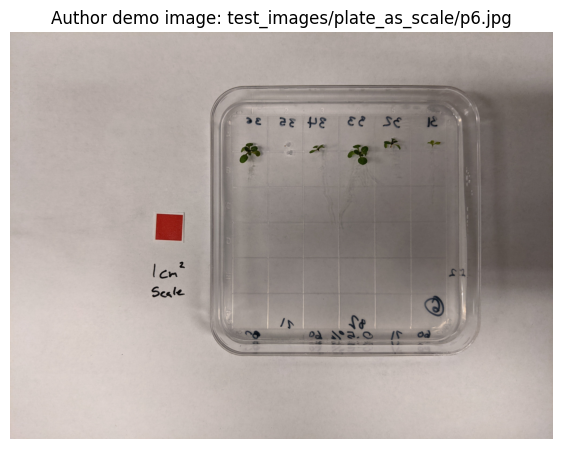

In [ ]:
import cv2
import matplotlib.pyplot as plt

image = cv2.imread("/content/test_images/plate_as_scale/p6.jpg")
assert image is not None, "image failed to load"
print("image shape (H, W, C):", image.shape)
plt.figure(figsize=(7, 7))
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.title("Author demo image: test_images/plate_as_scale/p6.jpg")
plt.axis("off")
plt.show()

## 4. Crop to the plate (author demo cells 2–6)

Canny edge detection → dilation → hole filling → erosion removes everything but the plate; the largest object defines the plate. `cv2.minAreaRect` of the plate gives the pixel size of the standard 10,000 mm² plate → `pixels_per_mm2_plate`. The image is cropped to the plate (with the authors' extra 0.95-width trim for this image set) and rotated if needed.

**Compatibility fix (the only functional change):** with the authors' OpenCV, `rect[2]` was `90.0`, so their rule (`if angle < 4.0 and angle > -4.0`) skipped rotation. OpenCV ≥ 4.5 returns the equivalent axis-aligned angle as `-90.0`, which their rule would rotate by −180°. We normalize `angle < -45 → angle += 180` before their rule, preserving their behavior.

Japanese: Canny→膨張→穴埋め→収縮でプレート以外を除去し、プレート領域のみを切り出します。標準プレート面積 10,000 mm² から画素→mm²変換係数を求めます。OpenCV ≥ 4.5 の角度規約変更のみ互換処理を入れています。

objects after filtering (should be 1 = the plate): 1
auto-cropped shape: (1731, 1727, 3)
minAreaRect: ((2493.0, 1402.9998779296875), (1969.999755859375, 1965.999755859375), -90.0)
pixels_per_mm2_plate = 387.301903906256
rotation applied (degrees): 0.0


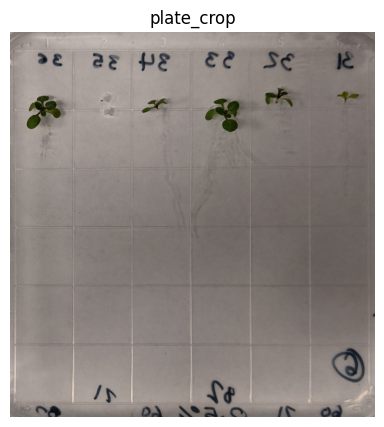

In [ ]:
import numpy as np

edges = pcv.canny_edge_detect(img=image, sigma=1.5, thickness=20, high_thresh=35, low_thresh=20)
dilate = pcv.dilate(gray_img=edges, ksize=39, i=2)
fill_image = pcv.fill_holes(bin_img=dilate)
erode = pcv.erode(gray_img=fill_image, ksize=561, i=1)
dilate = pcv.dilate(gray_img=erode, ksize=421, i=1)

id_objects, obj_hierarchy = pcv.find_objects(img=image, mask=dilate)
print("objects after filtering (should be 1 = the plate):", len(id_objects))

plate = id_objects[0]
plate_crop = pcv.auto_crop(img=image, obj=plate, padding_x=-120, padding_y=-120, color="image")
shape = plate_crop.shape
print("auto-cropped shape:", shape)
# extra trim specific to this image set (right rim slightly longer)
plate_crop = pcv.crop(img=plate_crop, x=0, y=0, h=shape[0], w=int(shape[1] * 0.95))

rect = cv2.minAreaRect(plate)
print("minAreaRect:", rect)
# plates are a standard size (10,000 mm^2): pixels per mm^2 from the plate itself
plate_px = rect[1][0] * rect[1][1]
pixels_per_mm2_plate = float(plate_px / 10000)
print("pixels_per_mm2_plate =", pixels_per_mm2_plate)

# --- COMPAT: cv2 >= 4.5 angle convention (see markdown above) ---
angle = rect[2]
if angle < -45:
    angle += 180
# --- end compat; author's rule unchanged below ---
if angle < 4.0 and angle > -4.0:
    plate_crop = pcv.transform.rotate(plate_crop, angle, False)
else:
    plate_crop = pcv.transform.rotate(plate_crop, angle - 90, False)
print("rotation applied (degrees):", angle - 90 if not (angle < 4.0 and angle > -4.0) else angle)

plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(plate_crop, cv2.COLOR_BGR2RGB))
plt.title("plate_crop")
plt.axis("off")
plt.show()

## 5. Identify rosettes: CMYK 'C' channel, blur, histogram, threshold (author demo cells 7–8)

The **cyan channel of CMYK** separates leaves from the agar for this image set. A Gaussian blur reduces noise, the intensity histogram guides the threshold choice, and a binary threshold at **50** ("light" objects) gives the leaf mask — parameters copied exactly from the pinned demo (the authors note thresholds are image-set specific).

Japanese: この画像セットでは CMYK の C（シアン）チャンネルが葉を抽出しやすいので、ブラー→ヒストグラム確認→閾値50の2値化を行います（閾値は画像セット固有のパラメータです）。

/usr/local/lib/python3.13/dist-packages/plantcv/plantcv/rgb2gray_cmyk.py:38: RuntimeWarning: invalid value encountered in divide
/usr/local/lib/python3.13/dist-packages/plantcv/plantcv/rgb2gray_cmyk.py:41: RuntimeWarning: invalid value encountered in divide
/usr/local/lib/python3.13/dist-packages/plantcv/plantcv/rgb2gray_cmyk.py:44: RuntimeWarning: invalid value encountered in divide
/usr/local/lib/python3.13/dist-packages/plantcv/plantcv/rgb2gray_cmyk.py:47: RuntimeWarning: invalid value encountered in cast


thresholded (leaf) pixels: 35133
leaf objects found: 6


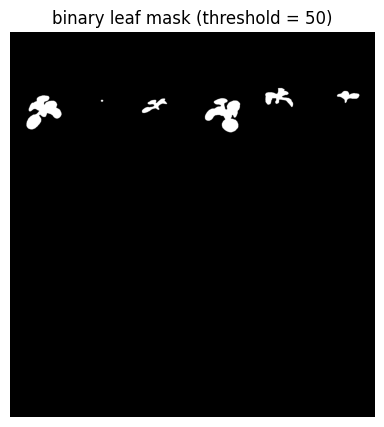

In [ ]:
img_bw = pcv.rgb2gray_cmyk(rgb_img=plate_crop, channel="c")
blur = pcv.gaussian_blur(img=img_bw, ksize=(13, 13), sigma_x=2, sigma_y=2)

hist_figure1, hist_data1 = pcv.visualize.histogram(blur, hist_data=True)
plt.show()

thresh = pcv.threshold.binary(gray_img=blur, threshold=50, max_value=255, object_type="light")
print("thresholded (leaf) pixels:", int(np.count_nonzero(thresh)))

id_objects, obj_hierarchy = pcv.find_objects(img=plate_crop, mask=thresh)
print("leaf objects found:", len(id_objects))

plt.figure(figsize=(5, 5))
plt.imshow(thresh, cmap="gray")
plt.title("binary leaf mask (threshold = 50)")
plt.axis("off")
plt.show()

## 6. Region of interest and clustering into six shoots (author demo cells 9–10)

Objects are kept only inside the ROI — for this image set: starting 1/9 of the plate height from the top, spanning 1/4 of the height and the full width — then grouped into six shoots with the authors' slightly modified `cluster_contours` (`cluster_jordan.py`) and split into individual plant images/masks.

Japanese: ROI（上から1/9、高さ1/4、幅いっぱい）内のオブジェクトを残し、著者改造版の `cluster_jordan` で6株にクラスタリングして分割します。

In [ ]:
shape = np.shape(plate_crop)
roi_contour, roi_hierarchy = pcv.roi.rectangle(img=plate_crop, x=0, y=shape[0] / 9, h=shape[0] / 4, w=shape[1])

roi_objects, hierarchy, kept_mask, obj_area = pcv.roi_objects(
    img=plate_crop, roi_contour=roi_contour, roi_hierarchy=roi_hierarchy,
    object_contour=id_objects, obj_hierarchy=obj_hierarchy, roi_type="partial")
print("objects inside ROI:", len(roi_objects))

clusters_i, contours, hierarchies = cluster_jordan.cluster_contours(
    img=plate_crop, roi_objects=roi_objects, roi_obj_hierarchy=hierarchy,
    nrow=2, ncol=6, show_grid=False)

output_path, imgs, masks = cluster_jordan.cluster_contour_splitimg(
    rgb_img=plate_crop, grouped_contour_indexes=clusters_i,
    contours=contours, hierarchy=hierarchies)
print("clusters:", clusters_i)
print("individual plant images:", len(imgs))

objects inside ROI: 6


This function has been updated to include object hierarchy so object holes can be included


clusters: [[np.int64(3)], [np.int64(0)], [np.int64(1)], [np.int64(2)], [np.int64(5)], [np.int64(4)]]
individual plant images: 6


## 7. Image moments per rosette (author demo cell 11)

For each clustered shoot, `cv2.moments` gives the leaf-pixel count (area in raw pixels). As in the demo, each rosette is sanity-checked against its minimum enclosing circle: if the rosette radius is ≤ 35 % of the enclosing circle's, a possible detection error is flagged.

Japanese: 各株の葉画素数を `cv2.moments` で数えます。外接円との比率から検出エラーの疑いも警告します。

In [ ]:
import math

sus = False
num_plants = 0
areas = {}

for i in range(0, 6):
    pos = 7 - (i + 1)
    if clusters_i[i][0] is not None:
        id_objects, obj_hierarchy = pcv.find_objects(img=imgs[num_plants], mask=masks[num_plants])
        obj, mask1 = pcv.object_composition(img=imgs[num_plants], contours=id_objects, hierarchy=obj_hierarchy)
        m = cv2.moments(obj)
        area = m["m00"]
        num_plants += 1
        center, expect_r = cv2.minEnclosingCircle(obj)
        r = math.sqrt(area / math.pi)
        if r <= 0.35 * expect_r:
            sus = True
            print(f"warning: there may be an error detecting leaf {pos}")
        areas[pos] = area
    else:
        areas[pos] = 0
print("raw leaf pixels per rosette:", areas)

raw leaf pixels per rosette: {6: 11692.0, 5: 65.0, 4: 2670.0, 3: 12435.5, 2: 4676.5, 1: 2393.0}


## 8. Dedicated red scale (author demo cells 12–13)

The demo also measures the red calibration scale in the photo (LAB **a** channel, threshold 140 over the full-image ROI), giving a second pixels→mm² factor (`scale_area` = 100 mm²). Both conversions are shown next, as in the paper.

Japanese: デモと同じく、LAB の a チャンネルで赤いスケールを検出し（閾値140）、もう一つの変換係数を求めます。

scale pixels: 39520.5
pixels_per_mm2_scale = 395.205


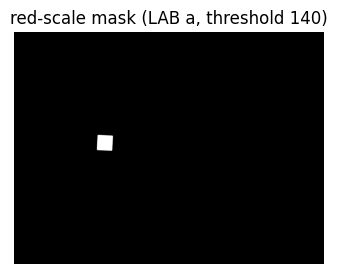

In [ ]:
shape = image.shape
roi_contour_scale, roi_hierarchy_scale = pcv.roi.rectangle(img=image, x=0, y=0, h=shape[0], w=shape[1])
scale = pcv.rgb2gray_lab(rgb_img=image, channel="a")
scale = pcv.gaussian_blur(img=scale, ksize=(21, 21), sigma_x=None, sigma_y=None)
scale_thresh = pcv.threshold.binary(gray_img=scale, threshold=140, max_value=255, object_type="light")
id_scale, obj_hierarchy = pcv.find_objects(img=image, mask=scale_thresh)
if len(obj_hierarchy) > 1:
    erode = pcv.erode(gray_img=scale_thresh, ksize=20, i=1)
    dilate = pcv.dilate(gray_img=scale_thresh, ksize=20, i=1)
    id_scale, obj_hierarchy = pcv.find_objects(img=image, mask=dilate)

roi_scale, scale_hierarchy, scale_mask, scale_area = pcv.roi_objects(
    img=image, roi_contour=roi_contour_scale, roi_hierarchy=roi_hierarchy_scale,
    object_contour=id_scale, obj_hierarchy=obj_hierarchy, roi_type="partial")
object_ = roi_scale[0]
m = cv2.moments(object_)
scale_pixels = m["m00"]
scale_area = 100  # mm^2
pixels_per_mm2_scale = float(scale_pixels) / scale_area
print("scale pixels:", scale_pixels)
print("pixels_per_mm2_scale =", pixels_per_mm2_scale)

plt.figure(figsize=(4, 4))
plt.imshow(scale_thresh, cmap="gray")
plt.title("red-scale mask (LAB a, threshold 140)")
plt.axis("off")
plt.show()

## 9. Results: rosette areas in mm² (author demo cell 14)

Converts the raw pixel counts with both scale factors and summarizes the result in a small table (CSV export included). A bar chart of per-rosette area is added as an extra visualization created for this notebook (not an author figure).

Japanese: 生画素数を2つの変換係数でmm²に換算し、表とCSV、追加の棒グラフで示します。

 position  raw_pixels  area_mm2_scale  area_mm2_plate
        6     11692.0           29.58           30.19
        5        65.0            0.16            0.17
        4      2670.0            6.76            6.89
        3     12435.5           31.47           32.11
        2      4676.5           11.83           12.07
        1      2393.0            6.06            6.18
saved /content/rosette_areas_p6.csv


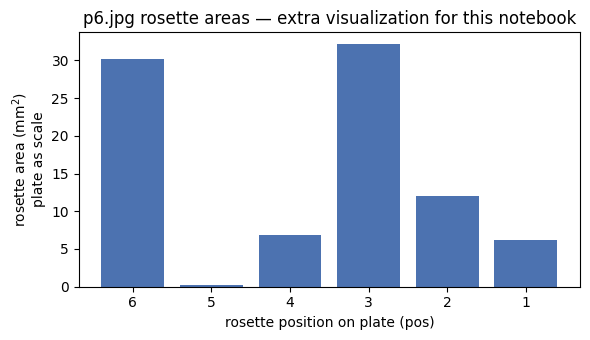

In [ ]:
import pandas as pd

converted_areas_scale = {pos: area / pixels_per_mm2_scale for pos, area in areas.items()}
conv_areas_plate = {pos: area / pixels_per_mm2_plate for pos, area in areas.items()}

df = pd.DataFrame({
    "position": sorted(areas, reverse=True),
    "raw_pixels": [areas[p] for p in sorted(areas, reverse=True)],
    "area_mm2_scale": [round(converted_areas_scale[p], 2) for p in sorted(areas, reverse=True)],
    "area_mm2_plate": [round(conv_areas_plate[p], 2) for p in sorted(areas, reverse=True)],
})
print(df.to_string(index=False))
df.to_csv("/content/rosette_areas_p6.csv", index=False)
print("saved /content/rosette_areas_p6.csv")

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar([str(p) for p in df["position"]], df["area_mm2_plate"], color="#4C72B0")
ax.set_xlabel("rosette position on plate (pos)")
ax.set_ylabel("rosette area (mm$^2$)\nplate as scale")
ax.set_title("p6.jpg rosette areas — extra visualization for this notebook")
plt.tight_layout()
plt.show()

## 10. Comparison with the authors' pinned demo outputs

The pinned `plate_as_scale_demo.ipynb` (commit `95fe490…`) contains the authors' saved outputs for this exact image. Their raw pixel areas were
`{6: 11692.0, 5: 65.0, 4: 2670.0, 3: 12435.5, 2: 4676.5, 1: 2393.0}`.

The cell below compares our executed results against that reference (expected: exact match for raw pixels; position 5 is the tiny 65 px rosette that the demo itself flags). Any difference would indicate a pipeline deviation.

Japanese: pinnedデモに保存されている著者の実行結果（生画素数）と比較します。生画素数は一致するはずです。

In [ ]:
author_reference = {6: 11692.0, 5: 65.0, 4: 2670.0, 3: 12435.5, 2: 4676.5, 1: 2393.0}
print(f"{'pos':>4} {'executed':>12} {'author demo':>12} {'diff':>10}")
max_abs = 0.0
for pos in sorted(author_reference, reverse=True):
    got = areas.get(pos, 0)
    diff = got - author_reference[pos]
    max_abs = max(max_abs, abs(diff))
    print(f"{pos:>4} {got:>12.1f} {author_reference[pos]:>12.1f} {diff:>10.1f}")
print("max |diff| =", max_abs, "raw px")
assert max_abs < 1.0, "executed areas deviate from the authors' pinned demo outputs"

 pos     executed  author demo       diff
   6      11692.0      11692.0        0.0
   5         65.0         65.0        0.0
   4       2670.0       2670.0        0.0
   3      12435.5      12435.5        0.0
   2       4676.5       4676.5        0.0
   1       2393.0       2393.0        0.0
max |diff| = 0.0 raw px


## 11. Interpretation and limitations

- **What was reproduced:** the authors' complete plate-as-scale + dedicated-scale demo on their own test image `p6.jpg`, with their pinned plantcv 3.14.1 and helper code. Raw pixel areas match the demo's saved outputs exactly (see §10); areas are ~2,400–12,400 raw px ≈ 6–32 mm² per rosette with the plate as scale.
- **What this does NOT verify:** the paper's validation statistics (R² regressions vs. overhead photos and seedling mass), the >2000-image diversity-panel batch (data not public), and the ANOVA/heritability results. One image demonstrates the method, not the paper's dataset-level conclusions.
- **Image-set specificity:** the authors stress that thresholds (50 for CMYK-C here, 140 for the scale) and the ROI geometry must be retuned per image set.
- **Compatibility adaptations** (documented above): cv2 ≥ 4.5 `minAreaRect` angle normalization; `np.int`/`np.int0` shims; scikit-image `graycomatrix` rename patch. No scientific parameter was changed.

**References**
1. Knapp et al., Appl. Plant Sci. 10(6):e11504, 2022. doi:10.1002/aps3.11504 (PMC9742823).
2. Author repository `massivejords/Agar-plate-leaf-area` @ `95fe49019f5716f6f12f2d0fba1b7c150ef0bea6` (`plate_as_scale_demo.ipynb`, `cluster_jordan.py`).
3. PlantCV: https://plantcv.org (v3.14.1).

**日本語まとめ:** 著者デモ画像 p6.jpg に対し、プレート検出→CMYK-C閾値50で葉抽出→6株クラスタリング→モーメントで葉面積（画素）→プレート面積(10,000 mm²)と赤スケールでmm²換算、までを実行しました。生画素数は著者の保存済み出力と一致します。これは手法の部分デモであり、論文のデータセット規模の検証（回帰・分散分析・遺伝率）は含みません。